In [1]:
%pip install ultralytics --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ultralytics import settings
settings.update({'dvc': False})

from ultralytics import YOLO
from pathlib import Path
import yaml

project_root       = Path(r'C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection')
dataset_root       = project_root / 'final_dataset.v1i.yolov8'
dataset_yaml       = dataset_root / 'data.yaml'
fixed_dataset_yaml = project_root / 'Training' / 'data.fixed.yaml'

with dataset_yaml.open('r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)
data_cfg['path'] = dataset_root.as_posix()
with fixed_dataset_yaml.open('w', encoding='utf-8') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print(f'Using data config: {fixed_dataset_yaml}')

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using data config: C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\data.fixed.yaml


In [ ]:
model = YOLO('yolov8n.pt')

results = model.train(
    data    = str(fixed_dataset_yaml),
    epochs  = 100,
    imgsz   = 640,
    batch   = 8,
    workers = 0,

    project  = str(project_root / 'Training' / 'runs' / 'detect'),
    name     = 'train_augmented',
    exist_ok = False,

    dropout         = 0.3,
    weight_decay    = 0.001,
    label_smoothing = 0.1,

    cos_lr        = True,
    lr0           = 0.005,
    lrf           = 0.005,
    warmup_epochs = 5,

    patience = 20,

    degrees     = 10.0,
    translate   = 0.15,
    scale       = 0.6,
    shear       = 5.0,
    perspective = 0.0005,
    fliplr      = 0.5,
    flipud      = 0.1,

    hsv_h   = 0.02,
    hsv_s   = 0.8,
    hsv_v   = 0.5,
    erasing = 0.4,

    mosaic       = 1.0,
    mixup        = 0.15,
    copy_paste   = 0.1,
    close_mosaic = 15,

    amp   = True,
    plots = True,
)

print(f'Best weights : {results.save_dir}/weights/best.pt')

New https://pypi.org/project/ultralytics/8.4.45 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.252  Python-3.13.5 torch-2.10.0+cpu CPU (11th Gen Intel Core(TM) i5-11400H 2.70GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\data.fixed.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.005, mask_rat

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/05/01 19:01:53 INFO mlflow.tracking.fluent: Experiment with name 'C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\runs\detect' does not exist. Creating a new experiment.


MLflow: logging run_id(648c0be958d44b15bf689525fcb0332b) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\runs\detect\train_augmented2
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100         0G      1.791      2.675      1.874         62        640: 100% ━━━━━━━━━━━━ 161/161 2.9s/it 7:402.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.6s/it 17.6s1.6s
                   all        161       1755      0.515      0.789      0.605       0.34

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100         0G      1.702      2.042      1.837        118      

In [2]:
from pathlib import Path
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

project_root       = Path(r'C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection')
fixed_dataset_yaml = project_root / 'Training' / 'data.fixed.yaml'

if 'model' not in globals() or 'results' not in globals():
    best_pt = project_root / 'Training' / 'runs' / 'detect' / 'train_augmented2' / 'weights' / 'best.pt'
    model = YOLO(str(best_pt))

metrics = model.val(data=str(fixed_dataset_yaml))
print(f'mAP50    : {metrics.box.map50:.4f}')
print(f'mAP50-95 : {metrics.box.map:.4f}')

Ultralytics 8.3.252  Python-3.13.5 torch-2.10.0+cpu CPU (11th Gen Intel Core(TM) i5-11400H 2.70GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 330.273.0 MB/s, size: 44.8 KB)
val: Scanning C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\final_dataset.v1i.yolov8\valid\labels.cache... 161 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 30.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.1s/it 11.8s1.1s
                   all        161       1755      0.877       0.86      0.894      0.555
                BROKEN        152        640      0.836      0.872      0.866      0.477
                 Empty        149        428      0.779       0.78        0.8      0.419
                    OK        156        450      0.966      0.815      0.935      0.537
                 strip        156        237      0

In [3]:
cm = metrics.confusion_matrix.matrix
names = metrics.names
class_names = [names[i] for i in sorted(names.keys())] if isinstance(names, dict) else list(names)
tick_labels = class_names + ['background']

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(len(tick_labels)), tick_labels, rotation=45, ha='right')
plt.yticks(np.arange(len(tick_labels)), tick_labels)
threshold = cm.max() / 2 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v = cm[i, j]
        plt.text(j, i, f'{int(v)}' if float(v).is_integer() else f'{v:.2f}',
                 ha='center', va='center', color='white' if v > threshold else 'black')
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 2 Axes>

In [4]:
import pandas as pd

ordered_class_names = [metrics.names[i] for i in sorted(metrics.names.keys())] \
    if isinstance(metrics.names, dict) else list(metrics.names)

box = metrics.box
rows = [{
    'Class': c,
    'Precision': float(box.p[i]),
    'Recall': float(box.r[i]),
    'mAP50': float(box.ap50[i]),
    'mAP50-95': float(box.ap[i])
} for i, c in enumerate(ordered_class_names)]

overall = {'Class': 'Overall', 'Precision': float(box.mp), 'Recall': float(box.mr),
           'mAP50': float(box.map50), 'mAP50-95': float(box.map)}

df = pd.DataFrame([overall] + rows)
df[['Precision','Recall','mAP50','mAP50-95']] = (df[['Precision','Recall','mAP50','mAP50-95']] * 100).round(2)
print('Model Performance Matrix (%)')
display(df)

Model Performance Matrix (%)


,Class,Precision,Recall,mAP50,mAP50-95
0,Overall,87.71,86.05,89.35,55.54
1,BROKEN,83.65,87.19,86.63,47.70
2,Empty,77.85,78.04,79.97,41.92
3,OK,96.58,81.49,93.52,53.67
4,strip,92.75,97.47,97.29,78.87


In [5]:
import cv2
from ultralytics import YOLO
from pathlib import Path

project_root = Path(r'C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection')

if 'model' not in globals():
    best_pt = project_root / 'Training' / 'runs' / 'detect' / 'train_augmented' / 'weights' / 'best.pt'
    model = YOLO(str(best_pt))

cap = cv2.VideoCapture(0)
print("Starting live detection. Press 'q' to stop.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    annotated = model(frame, verbose=False)[0].plot()
    cv2.imshow('PharmaVision – Live Detection', annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Starting live detection. Press 'q' to stop.


C:\Users\Admin\AppData\Local\Temp\ipykernel_11780\1482738643.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


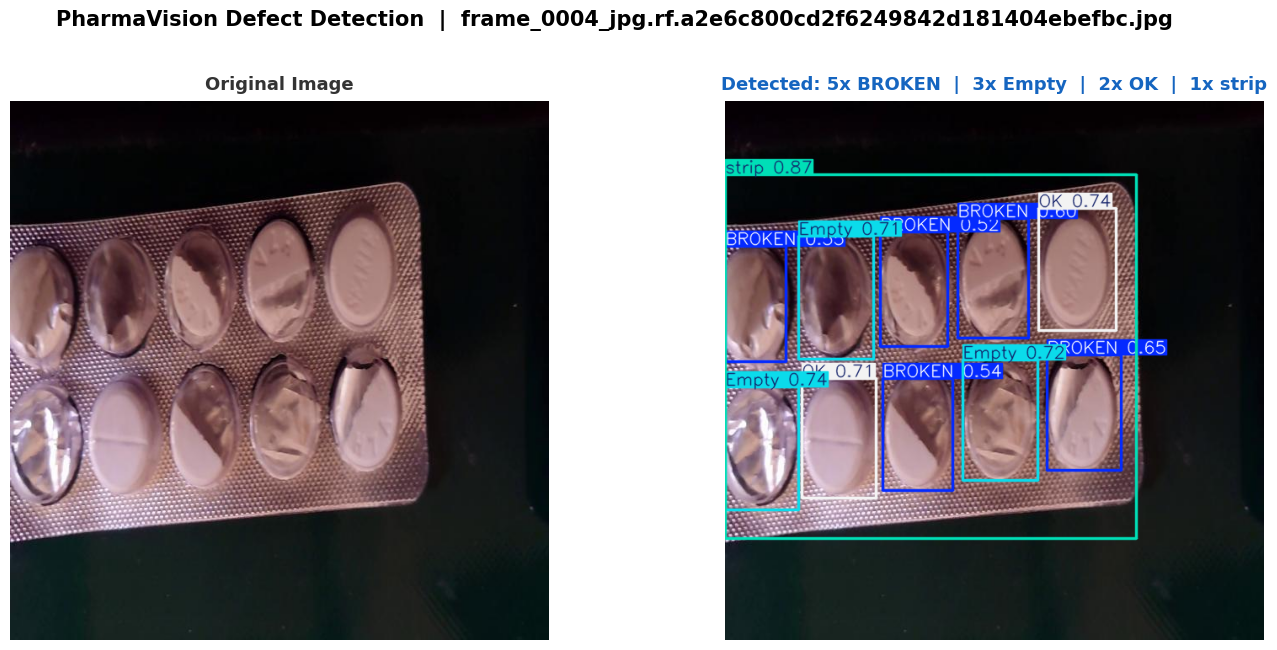

Image  : C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\final_dataset.v1i.yolov8\valid\images\frame_0004_jpg.rf.a2e6c800cd2f6249842d181404ebefbc.jpg
Model  : C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\Training\runs\detect\train_augmented2\weights\best.pt
Detections found: 11
  [1] strip       conf=0.873  box=(0,87)-(488,519)
  [2] Empty       conf=0.741  box=(0,339)-(87,485)
  [3] OK          conf=0.738  box=(372,127)-(464,272)
  [4] Empty       conf=0.719  box=(282,307)-(371,450)
  [5] Empty       conf=0.708  box=(87,160)-(176,306)
  [6] OK          conf=0.707  box=(91,329)-(179,471)
  [7] BROKEN      conf=0.654  box=(382,301)-(470,438)
  [8] BROKEN      conf=0.604  box=(276,139)-(360,281)
  [9] BROKEN      conf=0.553  box=(0,172)-(72,309)
  [10] BROKEN      conf=0.538  box=(187,329)-(270,462)
  [11] BROKEN      conf=0.520  box=(184,155)-(264,291)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# STATIC IMAGE DETECTION  -  uses best.pt from train_augmented2
# Change IMAGE_PATH to any image you want to run detection on.
# ─────────────────────────────────────────────────────────────────────────────
import cv2

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from ultralytics import YOLO

# ── CONFIG ────────────────────────────────────────────────────────────────────
IMAGE_PATH     = r'C:\path\to\your\image.jpg'   # <── change this
CONF_THRESHOLD = 0.25
# ─────────────────────────────────────────────────────────────────────────────

project_root = Path(r'C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection')
best_pt      = project_root / 'Training' / 'runs' / 'detect' / 'train_augmented2' / 'weights' / 'best.pt'


def detect_image(image_path, conf=CONF_THRESHOLD, show_labels=True, show_conf=True):
    """Run PharmaVision defect detection on a single image.

    Displays the ORIGINAL image next to the ANNOTATED result side-by-side.

    Args:
        image_path  : str or Path  - path to any image file.
        conf        : float        - confidence threshold (0-1).
        show_labels : bool         - draw class labels on boxes.
        show_conf   : bool         - draw confidence scores on boxes.

    Returns:
        result : ultralytics Result object
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')

    # ── load model & run prediction ──────────────────────────────────────────
    _model  = YOLO(str(best_pt))
    results = _model.predict(
        source=str(image_path),
        conf=conf,
        show_labels=show_labels,
        show_conf=show_conf,
        verbose=False,
    )
    result = results[0]

    # ── prepare images ───────────────────────────────────────────────────────
    original_bgr  = cv2.imread(str(image_path))
    original_rgb  = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    annotated_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

    # ── build detection summary ──────────────────────────────────────────────
    boxes = result.boxes
    if len(boxes):
        counts = {}
        for cls_id in boxes.cls.tolist():
            name = result.names[int(cls_id)]
            counts[name] = counts.get(name, 0) + 1
        det_summary = '  |  '.join(f'{v}x {k}' for k, v in sorted(counts.items()))
    else:
        det_summary = 'No detections above threshold'

    # ── side-by-side plot ────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 7))
    fig.suptitle(
        f'PharmaVision Defect Detection  |  {image_path.name}',
        fontsize=15, fontweight='bold', y=1.01
    )

    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.05)

    # Original
    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(original_rgb)
    ax0.axis('off')
    ax0.set_title('Original Image', fontsize=13, fontweight='bold', pad=8,
                  color='#333333')

    # Annotated
    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(annotated_rgb)
    ax1.axis('off')
    ax1.set_title(f'Detected: {det_summary}', fontsize=13, fontweight='bold',
                  pad=8, color='#1565C0')

    plt.tight_layout()
    plt.show()

    # ── console summary ──────────────────────────────────────────────────────
    print(f'Image  : {image_path}')
    print(f'Model  : {best_pt}')
    print(f'Detections found: {len(boxes)}')
    for i, (cls_id, conf_val, xyxy) in enumerate(
            zip(boxes.cls.tolist(), boxes.conf.tolist(), boxes.xyxy.tolist()), 1):
        name = result.names[int(cls_id)]
        x1, y1, x2, y2 = (int(v) for v in xyxy)
        print(f'  [{i}] {name:<10}  conf={conf_val:.3f}  box=({x1},{y1})-({x2},{y2})')

    return result


# ── RUN ───────────────────────────────────────────────────────────────────────
result = detect_image(r"C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection\final_dataset.v1i.yolov8\valid\images\frame_0004_jpg.rf.a2e6c800cd2f6249842d181404ebefbc.jpg")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING GRAPHS  –  reads results.csv from train_augmented2
# Saves PNGs to Training/ folder for use in project report.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

project_root = Path(r'C:\Users\Admin\Desktop\Projects\PharmaVision Defect Detection')
results_csv  = project_root / 'Training' / 'runs' / 'detect' / 'train_augmented2' / 'results.csv'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
epochs = df['epoch'].values

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})
STYLE = dict(linewidth=2, marker='o', markersize=4)

# ── Graph 1: Training vs Validation Loss ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training vs Validation Loss', fontsize=15, fontweight='bold', y=1.02)
loss_pairs = [
    ('train/box_loss', 'val/box_loss', 'Box Loss',   '#2196F3', '#FF5722'),
    ('train/cls_loss', 'val/cls_loss', 'Class Loss', '#4CAF50', '#E91E63'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss',   '#9C27B0', '#FF9800'),
]
for ax, (tr, va, title, ct, cv) in zip(axes, loss_pairs):
    ax.plot(epochs, df[tr], color=ct, label='Train', **STYLE)
    ax.plot(epochs, df[va], color=cv, label='Val',   **STYLE, linestyle='--')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(str(project_root / 'Training' / 'graph_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Graph 2: mAP Progression ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, df['metrics/mAP50(B)'],    color='#1565C0', label='mAP@50',    **STYLE)
ax.plot(epochs, df['metrics/mAP50-95(B)'], color='#43A047', label='mAP@50-95', **STYLE, linestyle='--')
best_ep = df['metrics/mAP50(B)'].idxmax()
ax.axvline(epochs[best_ep], color='#E53935', linestyle=':', linewidth=1.5,
           label=f'Best epoch {int(epochs[best_ep])} (mAP50={df["metrics/mAP50(B)"].max():.3f})')
ax.set_title('mAP Progression over Training Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP'); ax.set_ylim(0, 1); ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(str(project_root / 'Training' / 'graph_map_progression.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Graph 3: Precision & Recall ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, df['metrics/precision(B)'], color='#7B1FA2', label='Precision', **STYLE)
ax.plot(epochs, df['metrics/recall(B)'],    color='#F57C00', label='Recall',    **STYLE, linestyle='--')
ax.set_title('Precision & Recall over Training Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Score'); ax.set_ylim(0, 1); ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(str(project_root / 'Training' / 'graph_precision_recall.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Graph 4: Per-class Bar Chart ──────────────────────────────────────────────
perf_data = {
    'Class':     ['BROKEN', 'Empty', 'OK',   'strip'],
    'Precision': [83.65,    77.85,   96.58,  92.75],
    'Recall':    [87.19,    78.04,   81.49,  97.47],
    'mAP50':     [86.63,    79.97,   93.52,  97.29],
    'mAP50-95':  [47.70,    41.92,   53.67,  78.87],
}
perf_df = pd.DataFrame(perf_data)
metrics_cols = ['Precision', 'Recall', 'mAP50', 'mAP50-95']
colors = ['#1E88E5', '#43A047', '#FB8C00', '#E53935']
x = np.arange(len(perf_df)); width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
for i, (col, color) in enumerate(zip(metrics_cols, colors)):
    bars = ax.bar(x + i * width, perf_df[col], width, label=col, color=color, alpha=0.88)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
ax.set_title('Per-Class Detection Performance (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Score (%)')
ax.set_xticks(x + width * 1.5); ax.set_xticklabels(perf_df['Class'], fontsize=11)
ax.set_ylim(0, 110); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(str(project_root / 'Training' / 'graph_per_class_performance.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Graph 5: Learning Rate Schedule ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs, df['lr/pg0'] * 1000, color='#00838F', label='LR (\u00d710\u207b\u00b3)', **STYLE)
ax.set_title('Learning Rate Schedule (Cosine Annealing + Warm-up)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate (\u00d710\u207b\u00b3)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True)); ax.legend()
plt.tight_layout()
plt.savefig(str(project_root / 'Training' / 'graph_lr_schedule.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n\u2705  All 5 graphs saved to Training/ folder.')
